In [1]:
import h5py
import torch
import numpy as np
import os
import json

import keyrank_rs

import torch.nn as nn

from tqdm import tqdm

In [2]:
from datafolder import DATAFOLDER

val_test_hdf = h5py.File(f"{DATAFOLDER}/simpleserial-aes-fix-500-diff.hdf5")

val_test_traces = torch.Tensor(np.array(val_test_hdf['trace']))
val_test_plaintexts = torch.Tensor(np.array(val_test_hdf['data']))
val_test_keys = torch.Tensor(np.array(val_test_hdf['key']))

device = torch.device("cuda")

In [3]:
print(val_test_traces.shape)
print(val_test_plaintexts.shape)
print(val_test_keys.shape)

torch.Size([1000, 500, 5000])
torch.Size([1000, 500, 32])
torch.Size([1000, 16])


In [4]:
s_box = [
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16,
]

In [5]:
val_test_sbox_output = torch.empty((1000,500,2,16))

# Outer loop is each of only 1000 different keys in testing set
for key_idx in range(val_test_traces.shape[0]):
    for idx, (key, plaintext) in enumerate(zip(val_test_keys[key_idx], val_test_plaintexts[key_idx])):

        pt = plaintext.clone()
        block1 = pt[:16]
        block2 = pt[16:]

        block1.map_(key, lambda x,y: s_box[int(x) ^ int(y)])
        block2.map_(key, lambda x,y: s_box[int(x) ^ int(y)])

        block1,block2 = block1.long(),block2.long()

        val_test_sbox_output[key_idx, idx, 0] = block1
        val_test_sbox_output[key_idx, idx, 1] = block2


In [6]:
def metadata_best_epoch(model_name) -> int:
    with open(f"models/{model_name}/metadata.json") as f:
        metadata = json.load(f)
        val_scores = metadata["scores"][1]
        best_epoch = np.array(val_scores).argmin()
    return best_epoch.item()

def get_traces_mean_std(trace_start, trace_end):
    """Load the mean and std of the training trace set within the given interval"""
    with open(f"misc/standardization/trace{trace_start}_{trace_end}.json") as f:
        info = json.load(f)
        mean = info['training_traces_mean']
        std = info['training_traces_std']

    return mean, std

In [7]:
IMPL = "fixslice"
ARCH = "zhang"
PREDICTION_TARGET = "sbox"
TARGET_BYTE_IDX = 12
TRACE_START = 400
TRACE_END = 1500
SEED = 777

INTERVAL_SIZE = TRACE_END - TRACE_START

model_name = f"{IMPL}-{PREDICTION_TARGET}-byte{TARGET_BYTE_IDX}-{ARCH}-{TRACE_START}_{TRACE_END}-s{SEED}"

epoch = metadata_best_epoch(model_name)

model_path = f"models/{model_name}/epoch{epoch}.pt"
print(model_path)

model = torch.load(model_path).to()

models/fixslice-sbox-byte12-zhang-400_1500-s777/epoch7.pt


/tmp/ipykernel_7175/1179452070.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(model_path).to()


In [8]:
traces_mean, traces_std = get_traces_mean_std(TRACE_START, TRACE_END)

all_traces = (val_test_traces[:, :, TRACE_START:TRACE_END] - traces_mean) / traces_std
block1_plaintext = val_test_plaintexts[:, :, :16] # first plaintext block
block2_plaintext = val_test_plaintexts[:, :, 16:] # second plaintext block
keys = val_test_keys
block1_sbox_output = val_test_sbox_output[:, :, 0, :]

print(f"Traces: {all_traces.shape}")
print(f"Plaintexts: {block1_plaintext.shape}")
print(f"Keys: {keys.shape}")
print(f"Sbox outputs: {block1_sbox_output.shape}")

Traces: torch.Size([1000, 500, 1100])
Plaintexts: torch.Size([1000, 500, 16])
Keys: torch.Size([1000, 16])
Sbox outputs: torch.Size([1000, 500, 16])


In [9]:
from captum.attr._utils.lrp_rules import EpsilonRule
from captum.attr import LRP

layer_lrp = LRP(model)


ATTACK_SUBKEY = TARGET_BYTE_IDX


total_attr = torch.zeros(INTERVAL_SIZE)
total_abs_attr = torch.zeros(INTERVAL_SIZE)

traces = all_traces[0] 
sboxes = block1_sbox_output[0, :, ATTACK_SUBKEY]

for mod in model.modules():
    mod.rule = EpsilonRule()

targets = [(sbox,) for sbox in sboxes.long().tolist()]

attr = layer_lrp.attribute(traces.to(device), target=targets).squeeze()
attr = attr.detach().cpu()
total_attr = total_attr + attr.sum(dim=0)
total_abs_attr = total_abs_attr + attr.abs().sum(dim=0)

torch.cuda.empty_cache()


total_attr = total_attr.detach().numpy()
total_abs_attr = total_abs_attr.detach().numpy()
    

/home/ulrik/miniconda3/envs/INF265/lib/python3.12/site-packages/captum/attr/_core/lrp.py:207: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(input_tuple)


In [10]:
import json
import numpy as np

snr_folder = "misc/snr/fixslice"

TRACE_START = 0
TRACE_END = 1600

def load_sbox_snr(byte, pt):
    with open(f"{snr_folder}/sbox_byte{byte}_pt{pt}.json", 'r') as f:
        data = json.load(f)
    return data['snr'][TRACE_START:TRACE_END]

def load_key_snr(byte):
    with open(f"{snr_folder}/key_byte{byte}.json", 'r') as f:
        data = json.load(f)
    return data['snr'][TRACE_START:TRACE_END]

ValueError: x and y must have same first dimension, but have shapes (1600,) and (1100,)

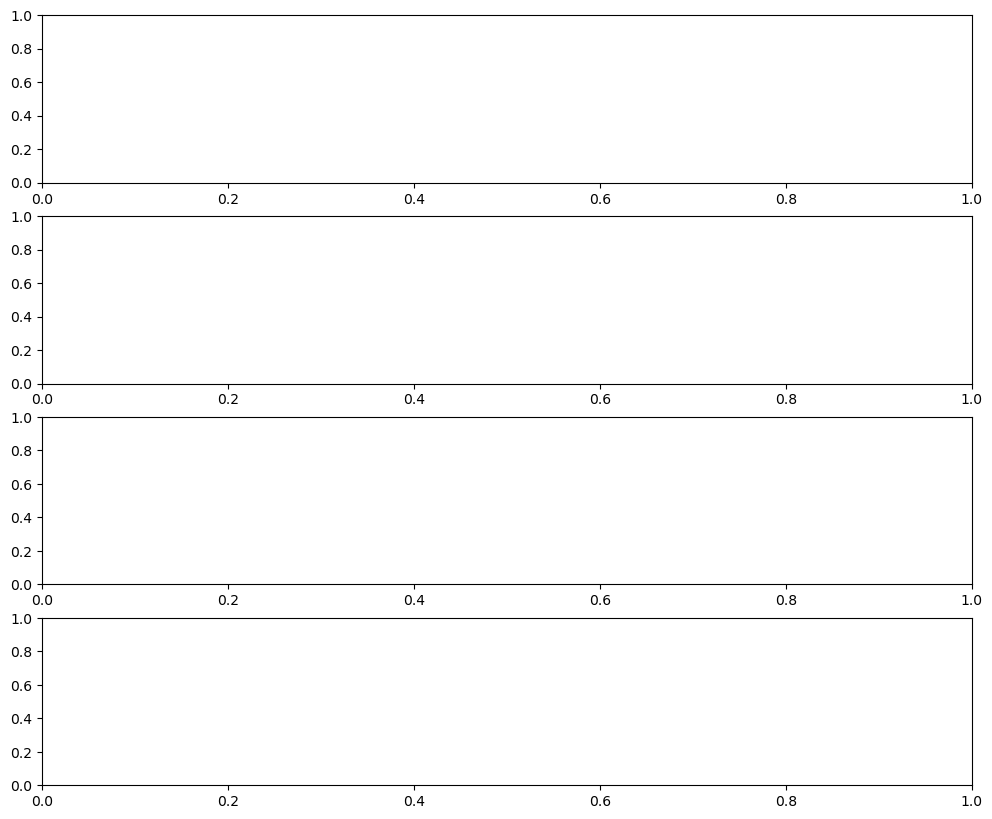

In [11]:
import matplotlib.pyplot as plt

x_values = np.arange(TRACE_START, TRACE_END)


fig, axes = plt.subplots(4, 1, figsize=(12,10))


axes[0].plot(x_values, total_attr, color='purple')
axes[0].set_title("LRP")

axes[1].plot(x_values, total_abs_attr, color='purple')
axes[1].set_title("Absolute LRP")

axes[2].plot(x_values, load_sbox_snr(ATTACK_SUBKEY, 1), color='red')
axes[2].set_title("SNR")
axes[2].set_ylim(0.0, 0.07)

axes[3].set_title("Sample trace")
axes[3].plot(x_values, all_traces[0][0])

plt.tight_layout()


ValueError: x and y must have same first dimension, but have shapes (1600,) and (1100,)

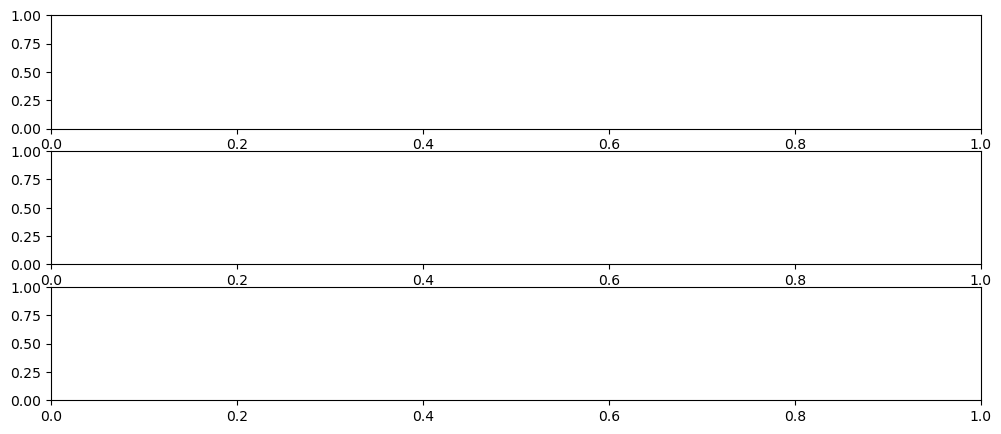

In [12]:
import matplotlib.pyplot as plt

x_values = np.arange(TRACE_START, TRACE_END)


fig, axes = plt.subplots(3, 1, figsize=(12,5))

axes[0].plot(x_values, total_attr, 'r')

axes[1].plot(x_values, total_abs_attr, 'r')

axes[2].plot(x_values, all_traces[0][0])

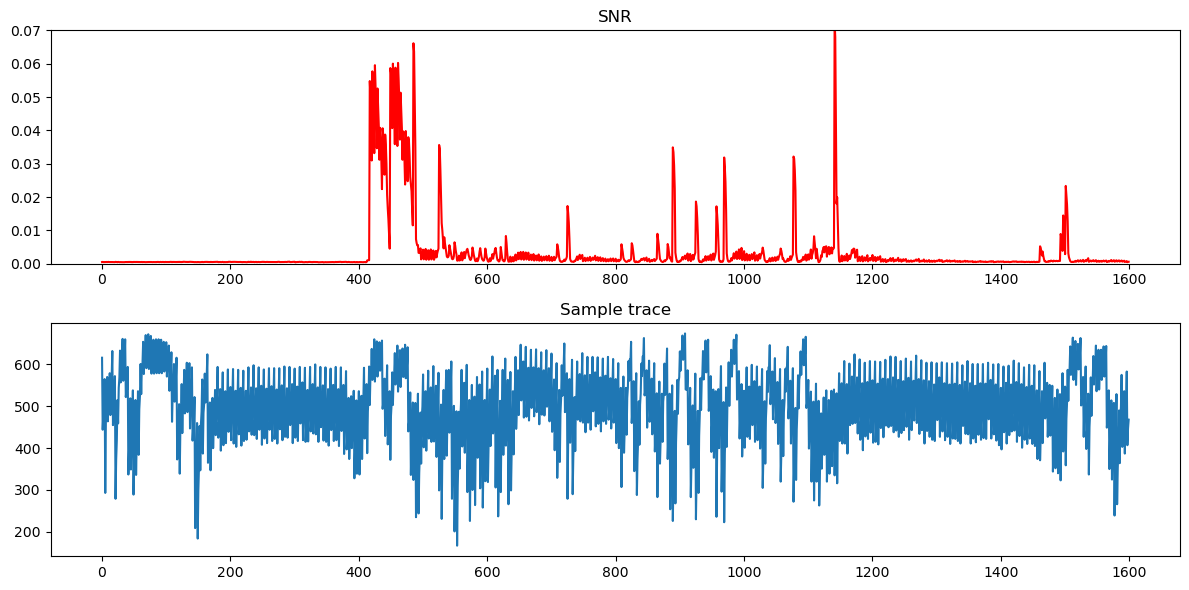

In [15]:
import matplotlib.pyplot as plt

x_values = np.arange(TRACE_START, TRACE_END)


fig, axes = plt.subplots(2, 1, figsize=(12.0,6.0))

axes[0].plot(x_values, load_key_snr(0), color='red')
axes[0].set_title("SNR")
axes[0].set_ylim(0.0, 0.07)

axes[1].set_title("Sample trace")
axes[1].plot(val_test_traces[0][0][0:1600])

#axes[0].set_yticks([])
#axes[1].set_yticks([])

plt.tight_layout()
